In [2]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import dill as pickle
import argparse
import json

import numpy as np
import healpy as hp

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpyro
from jax.example_libraries import stax

import numpyro.distributions as dist
from numpyro.infer import SVI, Predictive, Trace_ELBO, TraceGraph_ELBO, RenyiELBO, autoguide
from numpyro.infer.initialization import init_to_median, init_to_uniform
from numpyro.infer.reparam import NeuTraReparam
from numpyro.infer import MCMC, NUTS
from numpyro import optim
from numpyro.contrib.tfp.mcmc import ReplicaExchangeMC
from numpyro import handlers
from tensorflow_probability.substrates import jax as tfp

import optax
from einops import repeat

wdir = "/n/home07/yitians/fermi/fermi-prob-prog/production"
sys.path.append(f"{wdir}/..")
from models.scd import dnds
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.bulge_models import BulgeTemplates
from likelihoods.npll_jax import log_like_np
from likelihoods.pll_jax import log_like_poisson
from utils.sph_harm import Ylm
from utils import create_mask as cm
from models.psf import KingPSF
from utils.psf_correction import PSFCorrection

from utils.validation import roc_finite_sample_band
from utils.multi_corner import multi_corner

from models.np_model import NPModel

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

In [3]:
class Args:
    def __init__(self):
        self.i = 0
        self.n = 50000
        self.data = 'base23fix_2'
        self.model = 'base23fix'
        self.n_exp = 7
        self.n_step = 1000
        self.fit_type = 'svi'
        self.seed = 42
        self.lr = 1e-4
        self.lrexpdecay = False
        self.guide = "iaf"
        self.n_par = 8
        self.renyi_alpha = 1.0
        self.num_flows = 4
        self.hidden_dim_n = 64
        self.comment = ""

args = Args()

In [4]:
wdir = "/n/home07/yitians/fermi/fermi-prob-prog/production"
comment_str = '' if args.comment == '' else f"_{args.comment}"
run_name = f"{args.fit_type}_D{args.data}_M{args.model}" + comment_str
print('run_name:', run_name)

save_dir = f"{wdir}/../outputs/fit/{run_name}"
os.makedirs(save_dir, exist_ok=True)

mask_roi = np.load(f"{wdir}/mask_roi.npy")
mask_norm = jnp.load(f"{wdir}/mask_norm.npy")

# Ensure mask_roi's length is divisible by args.n_exp
n_pix_remainder = int(np.sum(~mask_roi)) % args.n_exp
print(f'Pixel number: {int(np.sum(~mask_roi))}', end=' ')
if n_pix_remainder != 0:
    unmasked_indices = np.where(mask_roi == 0)[0]
    mask_roi[unmasked_indices[-n_pix_remainder:]] = 1
print(f'-> {int(np.sum(~mask_roi))} = {args.n_exp} * {int(np.sum(~mask_roi) / args.n_exp)}')

data = np.load(f"../outputs/sims/{args.data}.npy")[args.i]
if len(data) < hp.nside2npix(128):
    data_full = np.zeros(hp.nside2npix(128))
    data_full[~mask_norm] = data
    data_in = jnp.array(data_full, dtype=jnp.int32)
else:
    data_in = jnp.array(data, dtype=jnp.int32)

psf_tag = 'delta' if 'deltapsf' in args.model else 'king'
print('PSF:', psf_tag)
if '1b' in args.model:
    Model = NPModel1B
    print('Using NPModel1B model')
else:
    Model = NPModel
    print('Using NPModel model')
m = Model(data=data_in, psf_tag=psf_tag, n_exp=args.n_exp, custom_mask_roi=mask_roi)
# m.debug_exaggerate_exposure(5)

if 'pois' in args.model:
    model_type = 'pois'
else:
    model_type = 'np'

run_name: svi_Dbase23fix_2_Mbase23fix
Pixel number: 6839 -> 6839 = 7 * 977
PSF: king
Using NPModel model
Number of exposure regions: 7
Number of pixels in ROI: 6839
Using psf: king
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/production/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 112


In [11]:
def fit_svi(
    npmodel, model_name = 'np', rng_key=jax.random.PRNGKey(42),
    guide='iaf', num_flows=5, hidden_dims=[128, 128],
    n_steps=7500, lr=5e-3, num_particles=8, vectorize_particles=True, renyi_alpha=None,
    lr_exp_decay=False, init_state=None,
    **model_static_kwargs
):
    
    #===== model =====
    if model_name == 'np':
        model = npmodel.model
    elif model_name == 'pois':
        model = npmodel.model_pois
    else:
        raise NotImplementedError("Model not recognized. Use 'np' or 'pois'.")

    #===== guide =====
    iaf_kwargs = dict(num_flows=num_flows, hidden_dims=hidden_dims, nonlinearity=stax.Tanh)

    if guide == "mvn":
        npmodel.guide = autoguide.AutoMultivariateNormal(model)
        
    elif guide == "iaf":
        npmodel.guide = autoguide.AutoIAFNormal(model, **iaf_kwargs)
        
    elif guide == "iafm":
        class AutoIAFMixture(autoguide.AutoIAFNormal):
            def get_base_dist(npmodel):
                C = 8
                mixture = dist.MixtureSameFamily(
                    dist.Categorical(probs=jnp.ones(C) / C),
                    dist.Normal(jnp.arange(float(C)), 1.)
                )
                return mixture.expand([npmodel.latent_dim]).to_event()
        npmodel.guide = AutoIAFMixture(model, **iaf_kwargs)

    elif guide == "iafst":
        class AutoIAFStudentT(autoguide.AutoIAFNormal):
            def get_base_dist(npmodel):
                # For instance, a single StudentT distribution
                # with df=5, loc=0, scale=1 for the entire latent dimension
                return dist.StudentT(df=5.0, loc=0.0, scale=1.0).expand([npmodel.latent_dim]).to_event(1)
        npmodel.guide = AutoIAFStudentT(model, **iaf_kwargs)
        
    else:
        raise NotImplementedError
    
    #===== optimizer =====
    if lr_exp_decay:
        lr_schedule = optax.join_schedules(
            schedules=[
                optax.constant_schedule(lr),
                optax.exponential_decay(
                    init_value = lr,
                    transition_steps = 100,
                    decay_rate = 0.97,
                    staircase = False
                )
            ],
            boundaries=[2000]
        )
    else:
        lr_schedule = lr

    optimizer = optim.optax_to_numpyro(optax.chain(
        optax.clip(1.),
        optax.adam(lr_schedule),
    ))
    
    #===== loss =====
    if renyi_alpha != 1:
        loss = RenyiELBO(num_particles=num_particles, alpha=renyi_alpha)
        print(f'USING RENYI ELBO WITH ALPHA = {renyi_alpha}')
    else:
        loss = Trace_ELBO(num_particles=num_particles, vectorize_particles=vectorize_particles)

    #===== SVI =====
    npmodel.svi = SVI(model, npmodel.guide, optimizer, loss)
    npmodel.svi_results = run_svi(npmodel.svi, rng_key, n_steps, init_state=init_state, **model_static_kwargs)
    
    return npmodel.svi_results

In [16]:
from collections import namedtuple
from functools import partial
import warnings

import tqdm

import jax
from jax import jit, lax, random
from jax.example_libraries import optimizers
import jax.numpy as jnp

from numpyro.distributions import constraints
from numpyro.distributions.transforms import biject_to
from numpyro.handlers import replay, seed, substitute, trace
from numpyro.infer.util import helpful_support_errors, transform_fn
from numpyro.optim import _NumPyroOptim, optax_to_numpyro
from numpyro.util import find_stack_level

SVIState = namedtuple("SVIState", ["optim_state", "mutable_state", "rng_key"])
"""
A :func:`~collections.namedtuple` consisting of the following fields:
 - **optim_state** - current optimizer's state.
 - **mutable_state** - extra state to store values of `"mutable"` sites
 - **rng_key** - random number generator seed used for the iteration.
"""


SVIRunResult = namedtuple("SVIRunResult", ["params", "state", "losses"])
"""
A :func:`~collections.namedtuple` consisting of the following fields:
 - **params** - the optimized parameters.
 - **state** - the last :data:`SVIState`
 - **losses** - the losses collected at every step.
"""


def beta_schedule(num_steps, start_T=10.0, end_T=1.0, kind="geometric"):
    """
    Returns betas in (0,1], where beta = 1/T.
    Geometric is robust; cosine is a smooth alternative.
    """
    assert start_T >= end_T >= 1.0
    if kind == "geometric":
        # T_t = start_T * (end_T/start_T)^(t/(num_steps-1))
        t = jnp.linspace(0, 1, num_steps)
        T = start_T * (end_T / start_T) ** t
    elif kind == "cosine":
        # T_t = end_T + 0.5*(start_T-end_T)*(1+cos(pi * (1 - t)))
        t = jnp.linspace(0, 1, num_steps)
        T = end_T + 0.5 * (start_T - end_T) * (1.0 + jnp.cos(jnp.pi * (1.0 - t)))
    else:
        raise ValueError("kind must be 'geometric' or 'cosine'")
    return 1.0 / T  # beta = 1/T


def run_svi(
    svi,
    rng_key,
    num_steps,
    *args,
    progress_bar=True,
    stable_update=False,
    forward_mode_differentiation=False,
    init_state=None,
    init_params=None,
    **kwargs,
):

    if num_steps < 1:
        raise ValueError("num_steps must be a positive integer.")

    betas = beta_schedule(num_steps, kind="geometric")

    def body_fn(svi_state, beta, _):
        if stable_update:
            svi_state, loss = svi.stable_update(
                svi_state,
                *args,
                # forward_mode_differentiation=forward_mode_differentiation,
                beta=beta,
                **kwargs,
            )
        else:
            svi_state, loss = svi.update(
                svi_state,
                *args,
                # forward_mode_differentiation=forward_mode_differentiation,
                beta=beta,
                **kwargs,
            )
        return svi_state, loss

    if init_state is None:
        svi_state = svi.init(rng_key, *args, init_params=init_params, **kwargs)
    else:
        svi_state = init_state
    if progress_bar:
        losses = []
        with tqdm.trange(1, num_steps + 1) as t:
            batch = max(num_steps // 20, 1)
            for i in t:
                beta = betas[i - 1]
                svi_state, loss = jit(body_fn)(svi_state, beta, None)
                losses.append(jax.device_get(loss))
                if i % batch == 0:
                    if stable_update:
                        valid_losses = [x for x in losses[i - batch :] if x == x]
                        num_valid = len(valid_losses)
                        if num_valid == 0:
                            avg_loss = float("nan")
                        else:
                            avg_loss = sum(valid_losses) / num_valid
                    else:
                        avg_loss = sum(losses[i - batch :]) / batch
                    t.set_postfix_str(
                        "init loss: {:.4f}, avg. loss [{}-{}]: {:.4f}".format(
                            losses[0], i - batch + 1, i, avg_loss
                        ),
                        refresh=False,
                    )
        losses = jnp.stack(losses)
    else:
        svi_state, losses = lax.scan(body_fn, svi_state, None, length=num_steps)

    # XXX: we also return the last svi_state for further inspection of both
    # optimizer's state and mutable state.
    return SVIRunResult(svi.get_params(svi_state), svi_state, losses)

In [17]:
fit_svi(
    npmodel=m,
    model_name=model_type, n_steps=args.n_step, data=data_in, lr=args.lr,
    rng_key=jax.random.PRNGKey(args.seed),
    guide=args.guide, num_flows=args.num_flows, hidden_dims=[args.hidden_dim_n, args.hidden_dim_n],
    num_particles=args.n_par, vectorize_particles=True,
    renyi_alpha=args.renyi_alpha, lr_exp_decay=args.lrexpdecay
)
samples = m.get_svi_samples(num_samples=args.n)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [05:32<00:00,  3.00it/s, init loss: 2826.3577, avg. loss [951-1000]: 18913.8500]


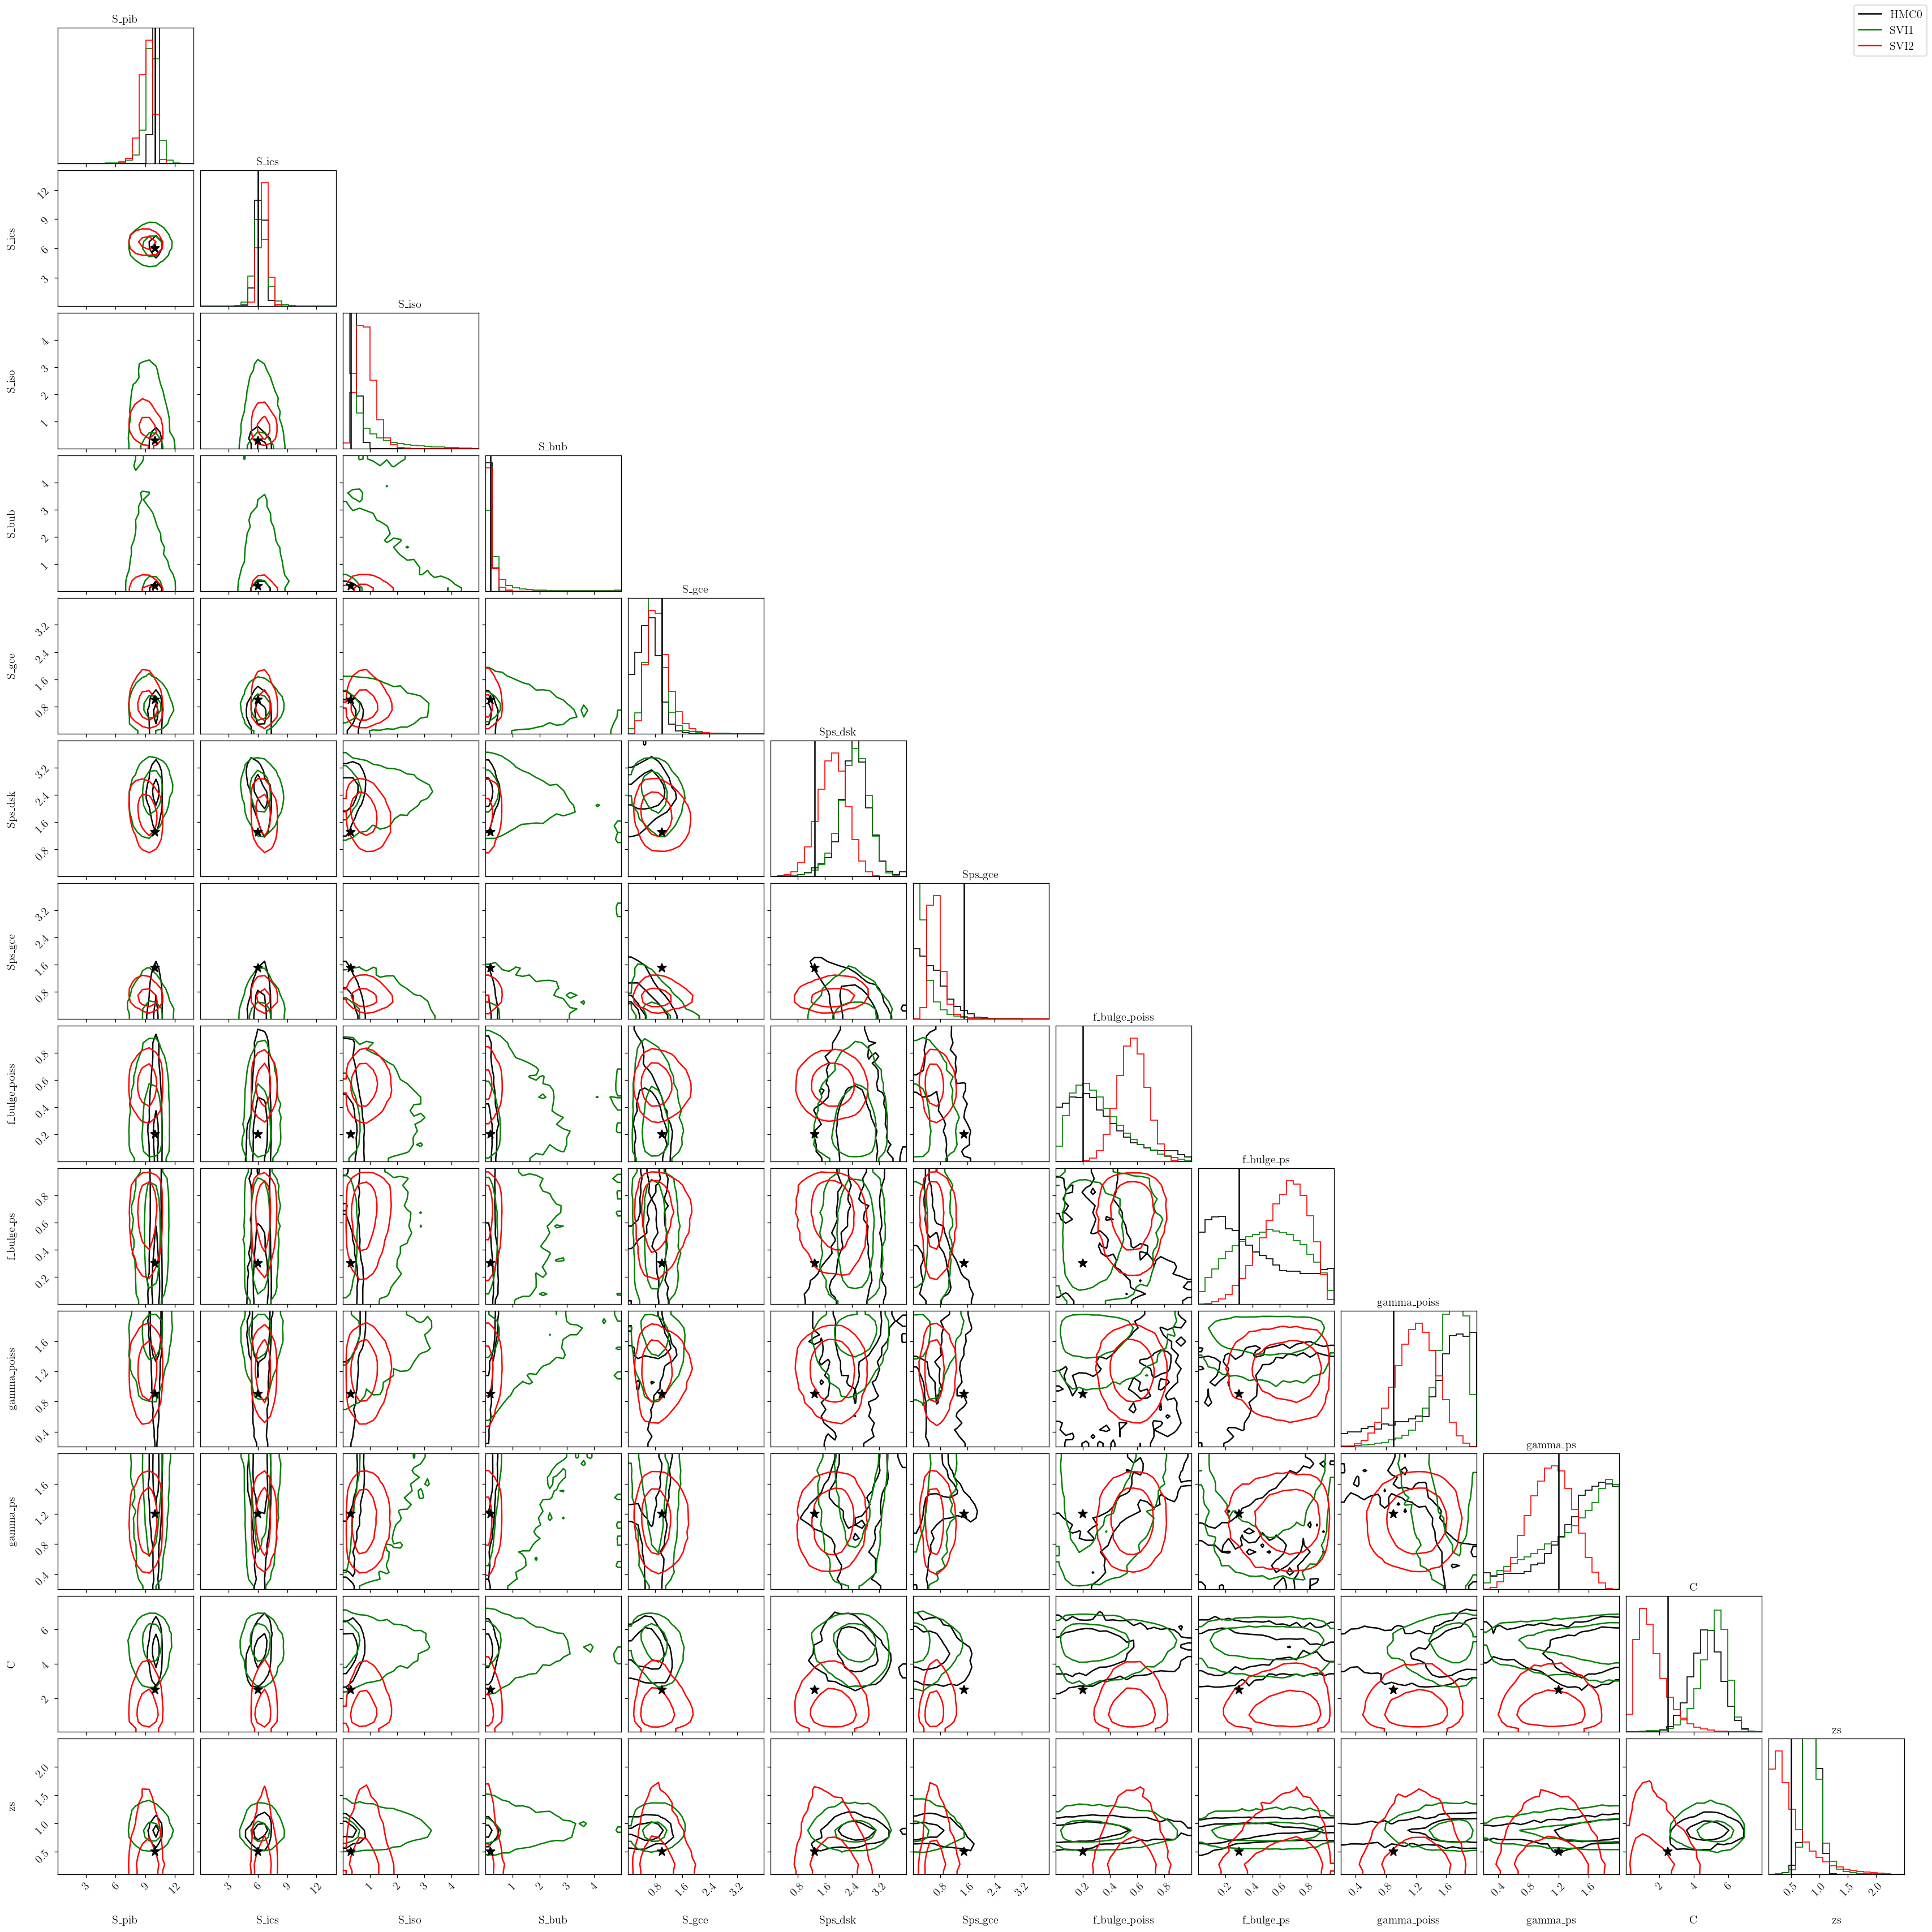

In [18]:
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce', 'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
config_dict = {
    'HMC0' : ('../outputs/fit/hmc_Dbase23fix_2_Mbase23fix/i0_n10000_ns0.p', 'k'),
    'SVI1' : ('../outputs/fit/svi_Dbase23fix_2_Mbase23fix_ns2000_a-1.0/i0_n50000_ns2000.p', 'g'),
    'SVI2' : ('this', 'r'),
}
truth_dict = json.load(open('truth_dict_base230927.json', 'r'))

s_in = {}
labels_dict = {}
colors_dict = {}
for key, (path, color) in config_dict.items():
    if path == 'this':
        s = samples
    else:
        s = pickle.load(open(path, 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = key
    colors_dict[key] = color

t_in = {k: truth_dict[k] for k in labels}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)